# Customer Value Cube — Analytical Reports & Visualisations
Data source: `customer_value_cube.csv`
Dimensions: `cohort_year` (Registration Cohort), `member_type` (NORMAL / VIP), `restaurant_cat` (Category)
Measures: `order_count`, `total_revenue`, `avg_order_value`

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import os

In [26]:
# Load and clean dataset
df = pd.read_csv("customer_value_cube.csv", header=None, names=[ 
    "cohort_year", "member_type", "restaurant_cat",
    "order_count", "total_revenue", "avg_order_value"
])

# Remove header row if present and cast numeric types
df = df[pd.to_numeric(df["cohort_year"], errors="coerce").notnull()].copy()
df["cohort_year"] = df["cohort_year"].astype(int)
df["order_count"] = df["order_count"].astype(int)
df["total_revenue"] = df["total_revenue"].astype(float)
df["avg_order_value"] = df["avg_order_value"].astype(float)

PALETTE = {"NORMAL": "#4C9BE8", "VIP": "#F5A623"}
CATS = sorted(df["restaurant_cat"].unique())
YEARS = sorted(df["cohort_year"].unique())

print(f"Cohort Years available: {YEARS}")
df.head()

Cohort Years available: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


,cohort_year,member_type,restaurant_cat,order_count,total_revenue,avg_order_value
0,2016,NORMAL,Beverage House,22,2286.20,103.92
1,2016,NORMAL,Chinese Cuisine,77,6694.53,86.94
2,2016,NORMAL,Dessert Cafe,69,6596.15,95.60
3,2016,NORMAL,Fast Food Express,84,9323.56,110.99
4,2016,NORMAL,Indian Cuisine,88,11295.84,128.36


## VIZ 1 — Average Revenue Trend by Member Type (Cohort Year)
### Pattern: VIP vs NORMAL average revenue per order trajectory over cohort years

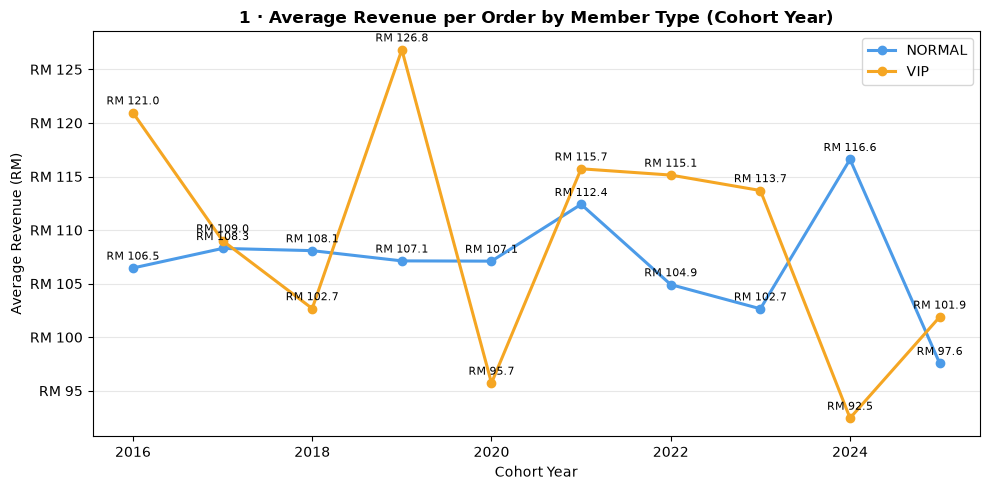

In [27]:
fig, ax1 = plt.subplots(figsize=(10, 5))

# Calculate average revenue per order by cohort year & member type
grp = df.groupby(["cohort_year", "member_type"]).agg(
    total_revenue=("total_revenue", "sum"),
    order_count=("order_count", "sum")
).reset_index()
grp["avg_revenue"] = grp["total_revenue"] / grp["order_count"]

for mtype, color in PALETTE.items():
    sub = grp[grp["member_type"] == mtype]
    ax1.plot(sub["cohort_year"], sub["avg_revenue"], marker="o",
             color=color, label=mtype, linewidth=2.2)
    for _, row in sub.iterrows():
        ax1.annotate(f'RM {row["avg_revenue"]:.1f}',
                     (row["cohort_year"], row["avg_revenue"]),
                     textcoords="offset points", xytext=(0, 6), ha="center", fontsize=8)

ax1.set_title("1 · Average Revenue per Order by Member Type (Cohort Year)", fontweight="bold")
ax1.set_xlabel("Cohort Year")
ax1.set_ylabel("Average Revenue (RM)")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'RM {x:.0f}'))
ax1.legend()
ax1.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## Revenue Composition — Stacked Bar Chart (NORMAL vs VIP by Year)
### Pattern: Proportion of total revenue contributed by VIP vs NORMAL members across cohort years

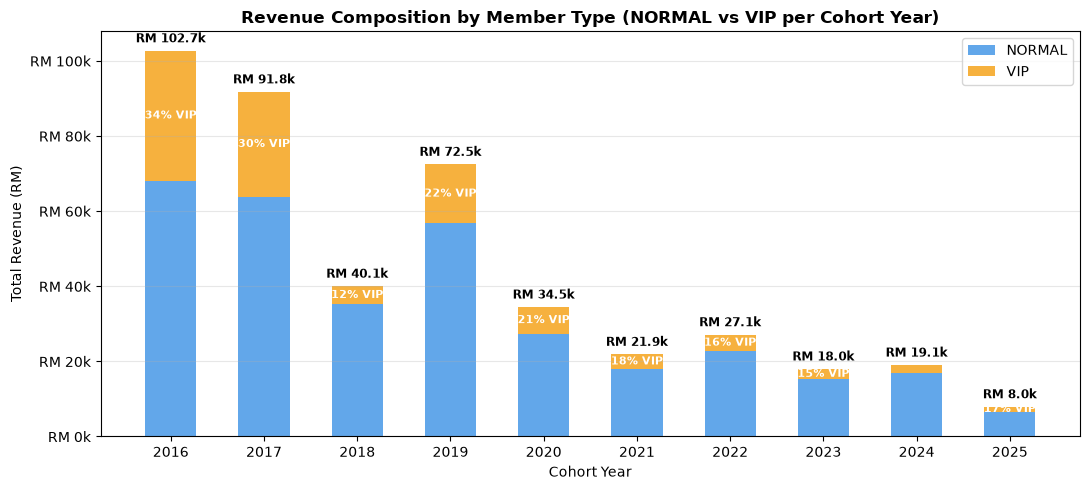

In [28]:
fig, ax_stack = plt.subplots(figsize=(11, 5))

# Pivot total revenue by cohort_year and member_type
pivot_rev = df.groupby(["cohort_year", "member_type"])["total_revenue"].sum().unstack(fill_value=0)
years = np.array(pivot_rev.index)
width = 0.55

# Stacked bars: NORMAL at bottom, VIP on top
p1 = ax_stack.bar(years, pivot_rev["NORMAL"], width, label="NORMAL", color=PALETTE["NORMAL"], alpha=0.88)
p2 = ax_stack.bar(years, pivot_rev["VIP"], width, bottom=pivot_rev["NORMAL"], label="VIP", color=PALETTE["VIP"], alpha=0.88)

# Add total revenue annotations on top and VIP percentage share labels
for yr in years:
    norm_val = pivot_rev.loc[yr, "NORMAL"]
    vip_val = pivot_rev.loc[yr, "VIP"]
    tot_val = norm_val + vip_val
    if tot_val > 0:
        # Total on top
        ax_stack.annotate(f'RM {tot_val/1000:.1f}k',
                          (yr, tot_val),
                          textcoords="offset points", xytext=(0, 6), ha="center", fontsize=8.5, fontweight="bold")
        # VIP share percentage inside VIP segment if noticeable
        vip_pct = (vip_val / tot_val) * 100
        if vip_val >= tot_val * 0.12:
            ax_stack.annotate(f'{vip_pct:.0f}% VIP',
                              (yr, norm_val + vip_val / 2),
                              ha="center", va="center", color="white", fontsize=8, fontweight="bold")

ax_stack.set_title("Revenue Composition by Member Type (NORMAL vs VIP per Cohort Year)", fontweight="bold")
ax_stack.set_xlabel("Cohort Year")
ax_stack.set_ylabel("Total Revenue (RM)")
ax_stack.set_xticks(years)
ax_stack.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'RM {x/1000:.0f}k'))
ax_stack.legend(loc="upper right")
ax_stack.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## VIZ 2 — Heatmap: Restaurant Category × Cohort Year (Total Revenue)
### Pattern: Which categories peak in which cohort years

In [ ]:
fig, ax2 = plt.subplots(figsize=(10, 6))

pivot = df.groupby(["restaurant_cat", "cohort_year"])["total_revenue"].sum().unstack(fill_value=0)
im = ax2.imshow(pivot.values, cmap="YlOrRd", aspect="auto")
ax2.set_xticks(range(len(pivot.columns)))
ax2.set_xticklabels(pivot.columns, rotation=45, ha="right", fontsize=8.5)
ax2.set_yticks(range(len(pivot.index)))
ax2.set_yticklabels(pivot.index, fontsize=8.5)
fig.colorbar(im, ax=ax2, label="Revenue (RM)")
ax2.set_title("2 · Revenue Heatmap: Category × Cohort Year", fontweight="bold")
ax2.set_xlabel("Cohort Year")
ax2.set_ylabel("Restaurant Category")

plt.tight_layout()
plt.show()

## VIZ 3 — Grouped Bar: Avg Order Value by Category (Drill-Down by Year)
### Pattern: VIP vs NORMAL willingness to pay across categories for a selected year or all years

In [ ]:
# Set selected_year to a specific cohort year (e.g. 2020) for drill down, or None for all years combined
selected_year = 2020  # Try changing to 2016, 2018, 2020, 2022, 2024, or None

def plot_aov_by_year(year=None):
    if year is not None:
        df_sub = df[df["cohort_year"] == year]
        title_suffix = f"(Drill Down — Cohort Year: {year})"
    else:
        df_sub = df
        title_suffix = "(All Cohort Years Combined)"
        
    grp3 = df_sub.groupby(["restaurant_cat", "member_type"])["avg_order_value"].mean().unstack()
    
    fig, ax3 = plt.subplots(figsize=(11, 5))
    x = np.arange(len(grp3.index))
    w = 0.35
    for i, mtype in enumerate(["NORMAL", "VIP"]):
        if mtype in grp3.columns:
            bars = ax3.bar(x + i * w, grp3[mtype], w, label=mtype,
                           color=PALETTE[mtype], alpha=0.85)
    
    ax3.set_xticks(x + w / 2)
    ax3.set_xticklabels(grp3.index, rotation=40, ha="right", fontsize=8)
    ax3.set_ylabel("Avg Order Value (RM)")
    ax3.set_title(f"3 · Avg Order Value by Category & Member Type {title_suffix}", fontweight="bold")
    ax3.legend()
    ax3.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

# Execute plot for selected year
plot_aov_by_year(selected_year)

## VIZ 4 — Stacked Area: Order Volume Trend by Member Type
### Pattern: Membership growth/decline rate, VIP order share over time

In [ ]:
fig, ax4 = plt.subplots(figsize=(10, 5))

grp4 = df.groupby(["cohort_year", "member_type"])["order_count"].sum().unstack(fill_value=0)
ax4.stackplot(grp4.index,
              grp4.get("NORMAL", pd.Series(0, index=grp4.index)),
              grp4.get("VIP",    pd.Series(0, index=grp4.index)),
              labels=["NORMAL", "VIP"],
              colors=[PALETTE["NORMAL"], PALETTE["VIP"]],
              alpha=0.75)
ax4.set_title("4 · Order Volume Trend (Stacked, by Member Type)", fontweight="bold")
ax4.set_xlabel("Cohort Year")
ax4.set_ylabel("Total Orders")
ax4.legend(loc="upper right")
ax4.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## VIZ 5 — Bubble Chart: Category Positioning (Drill-Down by Year)
### Pattern: High-value vs high-volume categories for a selected cohort year

In [ ]:
# Set year to drill down (e.g. 2020), or None for all years
drill_year = 2020

def plot_bubble_by_year(year=None):
    if year is not None:
        df_sub = df[df["cohort_year"] == year]
        title_suffix = f"(Cohort Year: {year})"
    else:
        df_sub = df
        title_suffix = "(All Years)"
        
    grp5 = df_sub.groupby("restaurant_cat").agg(
        total_revenue=("total_revenue", "sum"),
        avg_order_value=("avg_order_value", "mean"),
        order_count=("order_count", "sum")
    ).reset_index()
    
    fig, ax5 = plt.subplots(figsize=(11, 6))
    max_orders = grp5["order_count"].max() if grp5["order_count"].max() > 0 else 1
    bubble_sizes = (grp5["order_count"] / max_orders) * 3000
    
    scatter = ax5.scatter(
        grp5["total_revenue"],
        grp5["avg_order_value"],
        s=bubble_sizes,
        c=range(len(grp5)),
        cmap="tab10",
        alpha=0.75,
        edgecolors="white",
        linewidths=1.2
    )
    
    for _, row in grp5.iterrows():
        ax5.annotate(
            row["restaurant_cat"],
            (row["total_revenue"], row["avg_order_value"]),
            textcoords="offset points", xytext=(6, 4), fontsize=8
        )
    
    ax5.set_xlabel(f"Total Revenue (RM) — {title_suffix}")
    ax5.set_ylabel("Avg Order Value (RM)")
    ax5.set_title(f"5 · Category Positioning: Revenue vs Avg Order Value {title_suffix} (bubble = orders)",
                  fontweight="bold")
    ax5.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'RM {x/1000:.0f}k'))
    ax5.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_bubble_by_year(drill_year)